In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import numpy as np
import glob
import cv2
import random
import time

from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

# Dataset

*https://www.kaggle.com/datasets/kumaresanmanickavelu/lyft-udacity-challenge*

This dataset is available on Kaggle and is approximately **5GB** in size, so downloading it may take some time. However, you **don't need the entire dataset** to get started. It consists of five folders, and **downloading just one folder** will be sufficient for your needs.

*Important Notes*:
- **Kaggle API limitation**: You **cannot download individual folders** through the Kaggle API.
- **Manual download required**: To get a specific folder, you need to go to the [dataset page](https://www.kaggle.com/datasets/kumaresanmanickavelu/lyft-udacity-challenge) and download the `.tar` file manually.


In [2]:
# If using GG Colab, you need to upload file kaggle.json
from google.colab import files
files.upload()

{}

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
import kaggle
import os

dataset_url = 'kumaresanmanickavelu/lyft-udacity-challenge'
download_path = './road_dataset'

if os.path.isdir(download_path) and any(os.scandir(download_path)):
    print(f'Dataset already exists in {download_path}')
else:
    print(f'Downloading dataset from Kaggle: {dataset_url}')
    kaggle.api.dataset_download_files(dataset_url, path=download_path, unzip=True)
    print(f'Dataset downloaded and extracted to {download_path}')

Dataset already exists in ./road_dataset


In [5]:
def display_images(data_folder, num_to_display, shuffle=False):
    if num_to_display < 2 or num_to_display % 2 != 0:
        raise ValueError("num_to_display must be an even number and at least 2.")

    image_paths = glob.glob(f'./road_dataset/{data_folder}/{data_folder}/CameraRGB/*.png')  # returns list of file path
    mask_paths =  glob.glob(f'./road_dataset/{data_folder}/{data_folder}/CameraSeg/*.png')

    # Pick randomly images
    if shuffle:
        indices = random.sample(range(len(image_paths)), num_to_display)
        image_paths = [image_paths[i] for i in indices]
        mask_paths = [mask_paths[i] for i in indices]
    else:
        image_paths = image_paths[:num_to_display]
        mask_paths = mask_paths[:num_to_display]

    # Convert images to arrays
    image_arrs = [None] * num_to_display
    mask_arrs = [None] * num_to_display
    for i in range(num_to_display):
        image_arrs[i] = cv2.imread(image_paths[i])
        mask_arrs[i] = cv2.imread(mask_paths[i], cv2.IMREAD_GRAYSCALE)  # if not IMREAD_GRAYSCALE, images will be black

    # Visualize a pair of 2 images, 2 masks in each row
    fig, axes = plt.subplots(num_to_display//2, 4, figsize=(12, 12))
    axes = axes.flatten()
    for i in range(num_to_display):
        axes[2*i].imshow(image_arrs[i])
        axes[2*i + 1].imshow(mask_arrs[i], cmap='gray')
        axes[2*i].axis('off')
        axes[2*i + 1].axis('off')

    plt.tight_layout()
    plt.show()

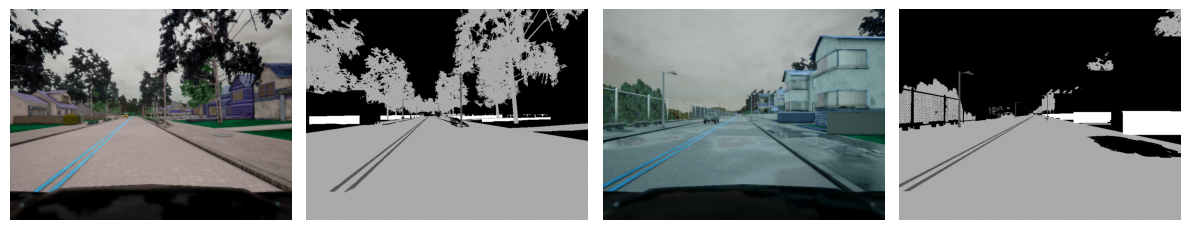

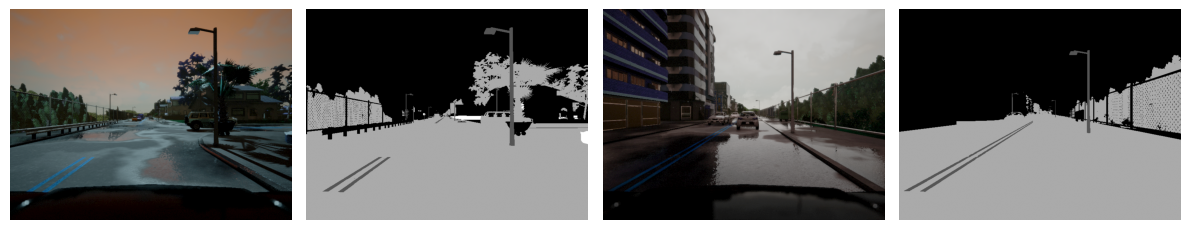

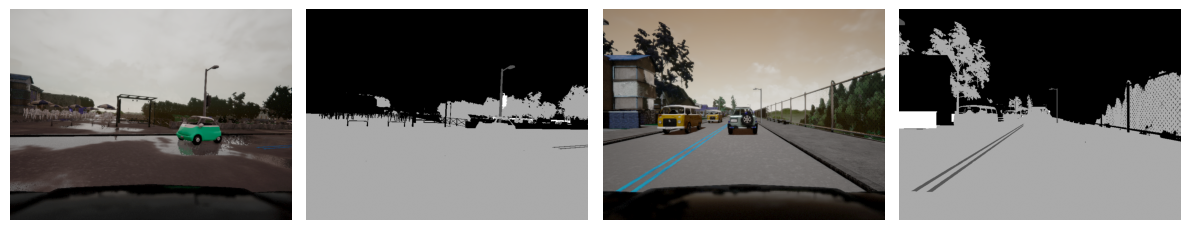

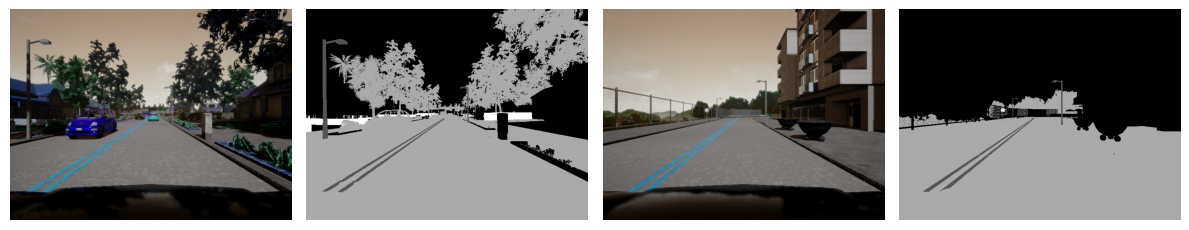

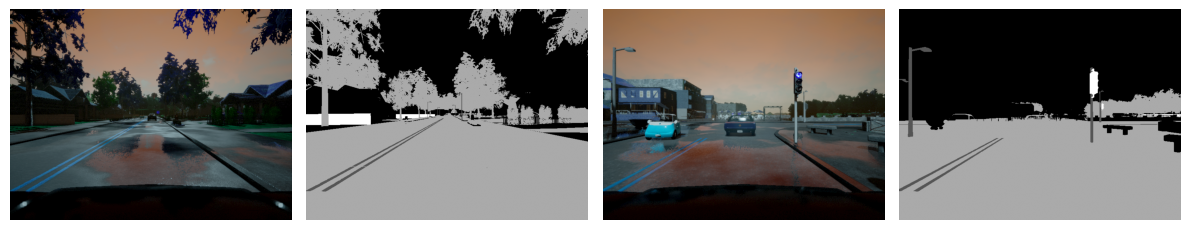

In [6]:
data_folders = ['dataA', 'dataB', 'dataC', 'dataD', 'dataE']

for i in range(len(data_folders)):
    display_images(data_folders[i], 2, shuffle=True)

# Data Preprocessing

In [7]:
image_paths = []
mask_paths = []

for folder in data_folders:
    images_each_folder = glob.glob(f'./road_dataset/{folder}/{folder}/CameraRGB/*.png')
    masks_each_folder = glob.glob(f'./road_dataset/{folder}/{folder}/CameraSeg/*.png')
    image_paths.extend(images_each_folder)
    mask_paths.extend(masks_each_folder)

len(image_paths), len(mask_paths)

(5000, 5000)

In [8]:
path_dataset = tf.data.Dataset.from_tensor_slices((tf.constant(image_paths), tf.constant(mask_paths)))
path_dataset

<_TensorSliceDataset element_spec=(TensorSpec(shape=(), dtype=tf.string, name=None), TensorSpec(shape=(), dtype=tf.string, name=None))>

In [9]:
def process_path(image_path, mask_path):
    image = tf.io.read_file(image_path)  # tensor of raw byte content, cannot read
    image = tf.image.decode_png(image, channels=3)  # decode to the tensor of shape (height, width, channels)
    image = tf.image.convert_image_dtype(image, tf.float32) # normalize from 0 to 1

    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=3)
    mask = tf.math.reduce_max(mask, axis=-1, keepdims=True)  # reduce from 3 channels to 1
    # no normalization on a mask because it contains each class for each pixel
    return image, mask

In [10]:
def resize_image(image, mask):
    IMAGE_SIZE = (256, 256)
    resized_image = tf.image.resize(image, IMAGE_SIZE, method='nearest')
    resized_mask = tf.image.resize(mask, IMAGE_SIZE, method='nearest')  # pick this method to preserve classes
    return resized_image, resized_mask

In [11]:
image_dataset = path_dataset.map(process_path)
image_dataset  # None in the shape indicates a dimension that is flexible or variable in size

<_MapDataset element_spec=(TensorSpec(shape=(None, None, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, None, 1), dtype=tf.uint8, name=None))>

In [12]:
image_dataset = image_dataset.map(resize_image)
image_dataset

<_MapDataset element_spec=(TensorSpec(shape=(256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(256, 256, 1), dtype=tf.uint8, name=None))>

In [13]:
# If you want to know the number of classes
n_classes = set()

for _, mask_tensor in image_dataset.take(1000):
    mask_array = mask_tensor.numpy()
    unique_values = np.unique(mask_array.flatten())
    n_classes.update(unique_values)

n_classes = sorted(n_classes)
n_classes

[np.uint8(0),
 np.uint8(1),
 np.uint8(2),
 np.uint8(3),
 np.uint8(4),
 np.uint8(5),
 np.uint8(6),
 np.uint8(7),
 np.uint8(8),
 np.uint8(9),
 np.uint8(10),
 np.uint8(11),
 np.uint8(12)]

# U-Net

U-Net, named for its U-shape, was originally created in 2015 for tumor detection, but in the years since has become a very popular choice for other semantic segmentation tasks.

U-Net builds on a previous architecture called the Fully Convolutional Network, or FCN, which replaces the dense layers found in a typical CNN with a transposed convolution layer that upsamples the feature map back to the size of the original input image, while preserving the spatial information. This is necessary because the dense layers destroy spatial information (the "where" of the image), which is an essential part of image segmentation tasks. An added bonus of using transpose convolutions is that the input size no longer needs to be fixed, as it does when dense layers are used.

Unfortunately, the final feature layer of the FCN suffers from information loss due to downsampling too much. It then becomes difficult to upsample after so much information has been lost, causing an output that looks rough.

U-Net improves on the FCN, using a somewhat similar design, but differing in some important ways. Instead of one transposed convolution at the end of the network, it uses a matching number of convolutions for downsampling the input image to a feature map, and transposed convolutions for upsampling those maps back up to the original input image size. It also adds skip connections, to retain information that would otherwise become lost during encoding. Skip connections send information to every upsampling layer in the decoder from the corresponding downsampling layer in the encoder, capturing finer information while also keeping computation low. These help prevent information loss, as well as model overfitting.

##### Model Details

<div style="text-align: center;">
    <img src="images/unet.png" style="width:800px;height:500px;" alt="Identity Block Diagram">
</div>

**Contracting path** (Encoder containing downsampling steps):

Images are first fed through several convolutional layers which reduce height and width, while growing the number of channels.

The contracting path follows a regular CNN architecture, with convolutional layers, their activations, and pooling layers to downsample the image and extract its features. In detail, it consists of the repeated application of two 3 x 3 same padding convolutions, each followed by a rectified linear unit (ReLU) and a 2 x 2 max pooling operation with stride 2 for downsampling. At each downsampling step, the number of feature channels is doubled.

**Crop function**: This step crops the image from the contracting path and concatenates it to the current image on the expanding path to create a skip connection.

**Expanding path** (Decoder containing upsampling steps):

The expanding path performs the opposite operation of the contracting path, growing the image back to its original size, while shrinking the channels gradually.

In detail, each step in the expanding path upsamples the feature map, followed by a 2 x 2 convolution (the transposed convolution). This transposed convolution halves the number of feature channels, while growing the height and width of the image.

Next is a concatenation with the correspondingly cropped feature map from the contracting path, and two 3 x 3 convolutions, each followed by a ReLU. You need to perform cropping to handle the loss of border pixels in every convolution.

**Final Feature Mapping Block**: In the final layer, a 1x1 convolution is used to map each 64-component feature vector to the desired number of classes. The channel dimensions from the previous layer correspond to the number of filters used, so when you use 1x1 convolutions, you can transform that dimension by choosing an appropriate number of 1x1 filters. When this idea is applied to the last layer, you can reduce the channel dimensions to have one layer per class.

The U-Net network has 23 convolutional layers in total.

##### Important Note:
The figures shown in the assignment for the U-Net architecture depict the layer dimensions and filter sizes as per the original paper on U-Net with smaller images. However, due to computational constraints for this assignment, you will code only half of those filters. The purpose of showing you the original dimensions is to give you the flavour of the original U-Net architecture. The important takeaway is that you multiply by 2 the number of filters used in the previous step. The notebook includes all of the necessary instructions and hints to help you code the U-Net architecture needed for this assignment.

### Encoder

In [14]:
def downsampling_block(input, n_filters, dropout_prob=0, max_pooling=True):
    conv = keras.layers.Conv2D(
        n_filters, kernel_size=(3,3), strides=(1,1), padding='same',
        activation='relu',
        kernel_initializer='he_normal')(input)

    conv = keras.layers.Conv2D(
        n_filters, kernel_size=(3,3), strides=(1,1), padding='same',
        activation='relu',
        kernel_initializer='he_normal')(conv)

    if dropout_prob > 0:
        conv = keras.layers.SpatialDropout2D(dropout_prob)(conv)

    residual = conv

    if max_pooling:
        pool = keras.layers.MaxPooling2D(pool_size=(2,2), strides=(2,2))(conv)
        return pool, residual

    return conv, residual

### Decoder

In [15]:
def upsampling_block(input, residual, n_filters):
    up_conv = keras.layers.Conv2DTranspose(n_filters, kernel_size=(2,2), strides=(2,2), padding='same')(input)
    concat = keras.layers.Concatenate(axis=3)([up_conv, residual])

    conv = keras.layers.Conv2D(
        n_filters, kernel_size=(3,3), strides=(1,1), padding='same',
        activation='relu',
        kernel_initializer='he_normal')(concat)

    conv = keras.layers.Conv2D(
        n_filters, kernel_size=(3,3), strides=(1,1), padding='same',
        activation='relu',
        kernel_initializer='he_normal')(conv)

    return conv

### Now, Build a Complete Model

In [16]:
def UNet(input_shape, n_filters, n_classes):
    input = keras.layers.Input(shape=input_shape)  # input_shape(H, W, 3)

    pool_1, res_1 = downsampling_block(input, n_filters)  # (H/2, W/2, C), (H, W, C)
    pool_2, res_2 = downsampling_block(pool_1, n_filters*2)  # (H/4, W/4, 2C), (H/2, W/2, 2C)
    pool_3, res_3 = downsampling_block(pool_2, n_filters*4, dropout_prob=0.1)  # (H/8, W/8, 4C), (H/4, W/4, 4C)
    pool_4, res_4 = downsampling_block(pool_3, n_filters*8, dropout_prob=0.1)  # (H/16, W/16, 8C), (H/8, W/8, 8C)

    conv_5, _ = downsampling_block(pool_4, n_filters*16, dropout_prob=0.1, max_pooling=False)  # (H/16, W/16, 16C)

    conv_6 = upsampling_block(conv_5, res_4, n_filters*8)  # (H/8, W/8, 8C)
    conv_7 = upsampling_block(conv_6, res_3, n_filters*4)  # (H/4, W/4, 4C)
    conv_8 = upsampling_block(conv_7, res_2, n_filters*2)  # (H/2, W/2, 2C)
    conv_9 = upsampling_block(conv_8, res_1, n_filters)  # (H, W, C)

    # conv_10 = keras.layers.Conv2D(
    #     n_filters, kernel_size=(3,3), strides=(1,1), padding='same',
    #     activation='relu',
    #     kernel_initializer='he_normal')(conv_9)  # (H, W, C)

    output = keras.layers.Conv2D(n_classes, kernel_size=(1,1), strides=(1,1), padding='same')(conv_9)  # (H, W, n_classes)

    model = keras.models.Model(inputs=input, outputs=output)
    return model

In [17]:
image_dataset.element_spec[0].shape

TensorShape([256, 256, 3])

In [18]:
INPUT_SHAPE = image_dataset.element_spec[0].shape
N_FILTERS = 32
N_CLASSES = len(n_classes)

unet = UNet(INPUT_SHAPE, N_FILTERS, N_CLASSES)
unet.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │      9,248 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │     36,928 │ conv2d_2[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │    147,584 │ conv2d_4[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout2d   │ (None, 64, 64,    │          0 │ conv2d_5[0][0]    │
│ (SpatialDropout2D)  │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 32,    │          0 │ spatial_dropout2… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │    295,168 │ max_pooling2d_2[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 32, 32,    │    590,080 │ conv2d_6[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout2d_1 │ (None, 32, 32,    │          0 │ conv2d_7[0][0]    │
│ (SpatialDropout2D)  │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 16, 16,    │          0 │ spatial_dropout2… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 16, 16,    │  1,180,160 │ max_pooling2d_3[… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 16, 16,    │  2,359,808 │ conv2d_8[0][0]  

 Total params: 7,760,493 (29.60 MB)

 Trainable params: 7,760,493 (29.60 MB)

 Non-trainable params: 0 (0.00 B)

# Training

In [19]:
N_SAMPLES = len(image_paths)
TRAIN_SIZE = int(0.7 * N_SAMPLES)
BUFFER_SIZE = 500
BATCH_SIZE = 64

# shuffle before split into train/val set, and then cache() to mark shuffled_dataset as a checkpoint (not repeat transformations before checkpoint) in pipeline
shuffled_dataset = image_dataset.shuffle(buffer_size=N_SAMPLES).cache()
# split
train_dataset = shuffled_dataset.take(TRAIN_SIZE).shuffle(buffer_size=BUFFER_SIZE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_dataset = shuffled_dataset.skip(TRAIN_SIZE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

shuffled_dataset, train_dataset, val_dataset

(<CacheDataset element_spec=(TensorSpec(shape=(256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(256, 256, 1), dtype=tf.uint8, name=None))>,
 <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 256, 256, 1), dtype=tf.uint8, name=None))>,
 <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 256, 256, 1), dtype=tf.uint8, name=None))>)

In [20]:
unet.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

In [21]:
EPOCHS = 50

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    min_delta=1e-4,
    restore_best_weights=True
)

history = unet.fit(
    train_dataset,
    epochs=EPOCHS,
    validation_data=val_dataset,
    callbacks=[early_stop]
)

Epoch 1/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 586s 5s/step - accuracy: 0.3552 - loss: 1.9347 - val_accuracy: 0.6720 - val_loss: 1.1526
Epoch 2/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 24s 429ms/step - accuracy: 0.7112 - loss: 0.9660 - val_accuracy: 0.8053 - val_loss: 0.6179
Epoch 3/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 23s 420ms/step - accuracy: 0.8320 - loss: 0.5520 - val_accuracy: 0.8768 - val_loss: 0.3955
Epoch 4/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 23s 423ms/step - accuracy: 0.8791 - loss: 0.3932 - val_accuracy: 0.9090 - val_loss: 0.2998
Epoch 5/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 23s 427ms/step - accuracy: 0.9091 - loss: 0.2952 - val_accuracy: 0.9198 - val_loss: 0.2580
Epoch 6/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 23s 425ms/step - accuracy: 0.9227 - loss: 0.2473 - val_accuracy: 0.9339 - val_loss: 0.2119
Epoch 7/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 23s 423ms/step - accuracy: 0.9348 - loss: 0.2080 - val_accuracy: 0.9401 - val_loss: 0.1883
Epoch 8/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 23s 425ms/step - accuracy: 0.9430 - loss: 0.1807 - val_accura

In [22]:
val_images = val_dataset.map(lambda x, y: x)
val_images

<_MapDataset element_spec=TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None)>

In [23]:
preds = unet.predict(val_images)
preds.shape, preds[:3, 0, 0]

24/24 ━━━━━━━━━━━━━━━━━━━━ 8s 269ms/step


((1500, 256, 256, 13),
 array([[ 10.8   ,   3.045 ,   0.628 ,  -1.593 ,  -5.29  ,   3.818 ,
         -10.336 ,   1.113 ,  -6.246 ,   5.703 ,  -1.055 ,  -3.129 ,
           1.411 ],
        [ 13.04  ,   3.266 ,   1.0205,  -2.041 ,  -6.258 ,   4.37  ,
         -12.11  ,   1.32  ,  -7.42  ,   6.688 ,  -1.242 ,  -3.732 ,
           1.356 ],
        [ 11.86  ,   3.523 ,   0.481 ,  -1.83  ,  -5.836 ,   4.23  ,
         -11.414 ,   1.432 ,  -6.945 ,   6.17  ,  -1.1   ,  -3.56  ,
           1.548 ]], dtype=float16))

In [24]:
pred_masks = tf.math.argmax(preds, axis=-1)  # returns index of max value'channel with tensor of shape (n_samples, height, width)
pred_masks = pred_masks[..., tf.newaxis]  # add a new axis at the end
pred_masks.shape

TensorShape([1500, 256, 256, 1])

In [25]:
val_images = []  # list containing batches of tensor
true_masks = []

for batch_x, batch_y in val_dataset:  # take each batch of BATCH_SIZE samples
    val_images.append(batch_x)  # batch_X.shape (BATCH_SIZE, H, W, C)
    true_masks.append(batch_y)  # batch_Y.shape (BATCH_SIZE, H, W, 1)

val_images = tf.concat(val_images, axis=0)  # concat batches of tensor into 1 batch
true_masks = tf.concat(true_masks, axis=0)

val_images.shape, true_masks.shape

(TensorShape([1500, 256, 256, 3]), TensorShape([1500, 256, 256, 1]))

In [26]:
def display_predictions(num_to_display, random=False):
  n_images = len(val_images)
  num_to_display = min(num_to_display, n_images)

  if random:
    indices = np.random.choice(n_images, num_to_display, replace=False)
  else:
    indices = range(num_to_display)

  fig, axes = plt.subplots(nrows=num_to_display, ncols=3, figsize=(12, 12*3))
  axes = axes.flatten()

  for i in range(num_to_display):
      idx = indices[i]

      axes[3*i].imshow(keras.preprocessing.image.array_to_img(val_images[idx]))
      axes[3*i].set_title(f"Validation Image {idx}")
      axes[3*i].axis('off')

      axes[3*i + 1].imshow(keras.preprocessing.image.array_to_img(true_masks[idx]))
      axes[3*i + 1].set_title(f"True Mask {idx}")
      axes[3*i + 1].axis('off')

      axes[3*i + 2].imshow(keras.preprocessing.image.array_to_img(pred_masks[idx]))
      axes[3*i + 2].set_title(f"Predicted Mask {idx}")
      axes[3*i + 2].axis('off')

  plt.tight_layout()
  plt.show()

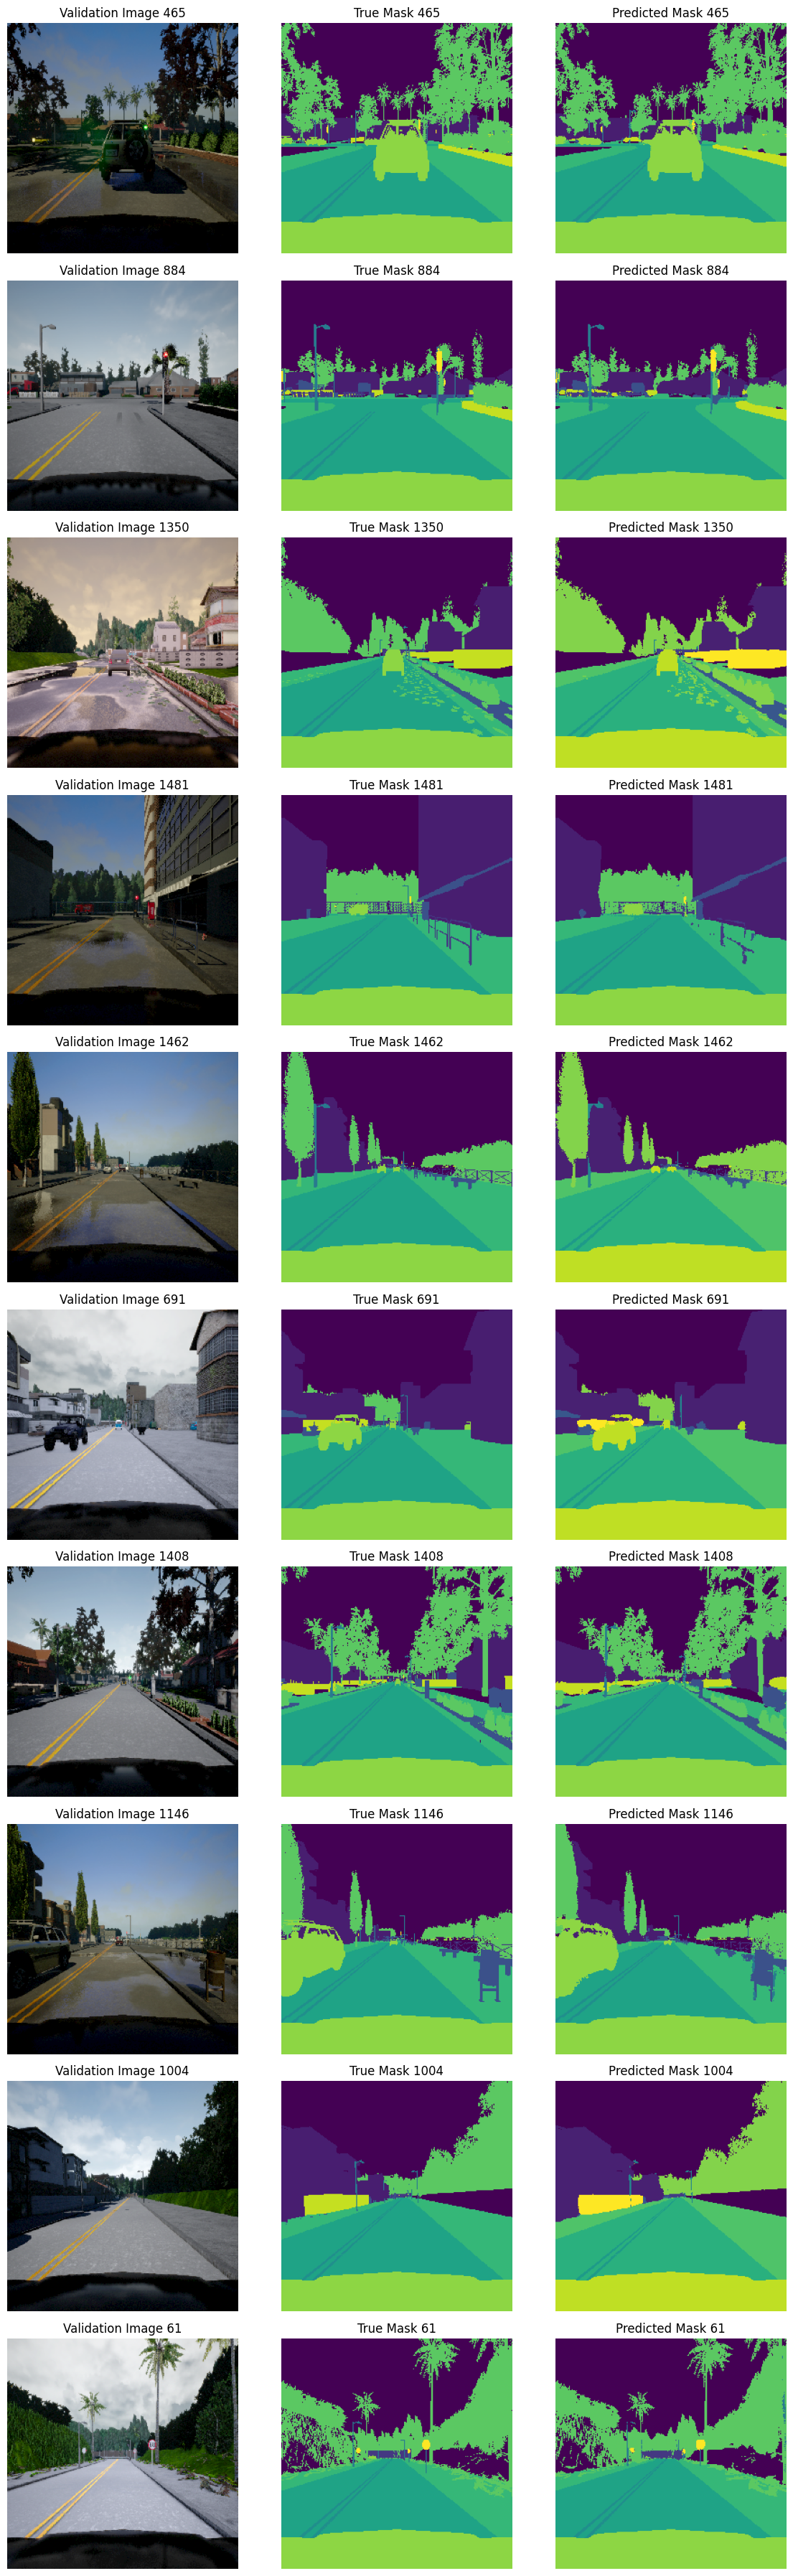

In [29]:
display_predictions(10, random=True)

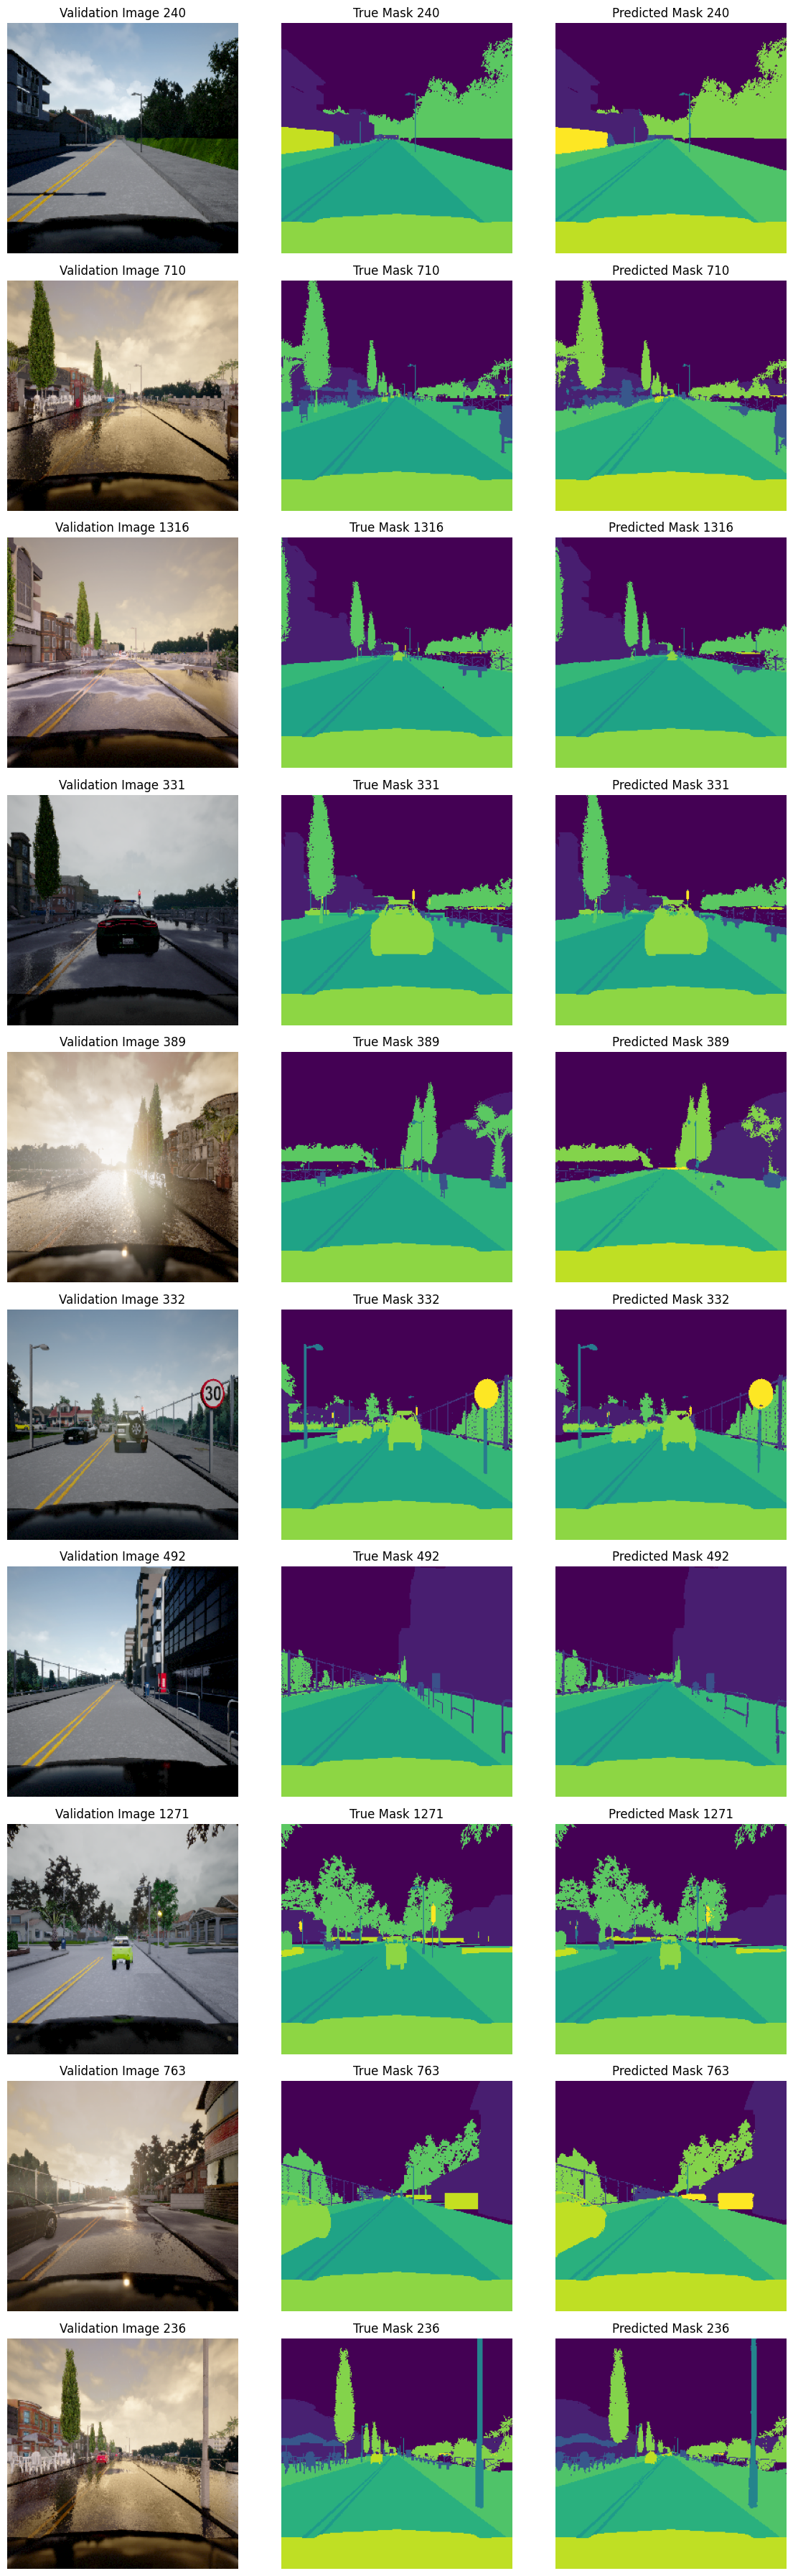

In [30]:
display_predictions(10, random=True)